In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
raw_dir = Path("../data/raw")

files = [
    raw_dir / "flights_2025_01.csv",
    raw_dir / "flights_2025_02.csv",
    raw_dir / "flights_2025_03.csv",
]

dfs = []

for file in files:
    temp = pd.read_csv(file, low_memory=False)
    print(file.name, temp.shape)
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

df.shape

flights_2025_01.csv (539747, 26)
flights_2025_02.csv (504884, 26)
flights_2025_03.csv (600872, 26)


(1645503, 26)

In [3]:
completed = df[
    (df["CANCELLED"] == 0) &
    (df["DIVERTED"] == 0) &
    (df["ARR_DEL15"].notna())
    ].copy()

completed.shape

(1611046, 26)

In [4]:
month_delay = (
    completed
    .groupby("MONTH")["ARR_DEL15"]
    .agg(["count", "mean"])
)

month_delay["late_rate_percent"] = month_delay["mean"] * 100

month_delay

,count,mean,late_rate_percent
MONTH,,,
1,522269,0.187892,18.789168
2,496476,0.207668,20.766764
3,592301,0.195904,19.590377


In [5]:
target = "ARR_DEL15"

numeric_features = [
    "MONTH",
    "DAY_OF_MONTH",
    "DAY_OF_WEEK",
    "CRS_DEP_TIME",
    "CRS_ARR_TIME",
    "DISTANCE",
    "DISTANCE_GROUP"
]

categorical_features = [
    "OP_UNIQUE_CARRIER",
    "ORIGIN",
    "DEST",
    "DEP_TIME_BLK",
    "ARR_TIME_BLK"
]

features = numeric_features + categorical_features

In [6]:
train_data = completed[completed["MONTH"].isin([1, 2])].copy()
test_data = completed[completed["MONTH"] == 3].copy()

X_train = train_data[features]
y_train = train_data[target].astype(int)

X_test = test_data[features]
y_test = test_data[target].astype(int)

X_train.shape, X_test.shape, y_train.mean(), y_test.mean()

((1018745, 12),
 (592301, 12),
 np.float64(0.1975293130273032),
 np.float64(0.19590377189976044))

In [7]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer_dense = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]
)

preprocessor_dense = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer_dense, categorical_features)
    ]
)

In [8]:
hgb_multi_month_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_dense),
        ("model", HistGradientBoostingClassifier(
            max_iter=100,
            learning_rate=0.1,
            max_leaf_nodes=31,
            random_state=42
        ))
    ]
)

hgb_multi_month_model.fit(X_train, y_train)

hgb_multi_probs = hgb_multi_month_model.predict_proba(X_test)[:, 1]

In [9]:
thresholds = np.arange(0.10, 0.501, 0.01)

multi_month_results = []

for threshold in thresholds:
    preds = (hgb_multi_probs >= threshold).astype(int)

    multi_month_results.append({
        "threshold": round(threshold, 2),
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0)
    })

multi_month_results_df = pd.DataFrame(multi_month_results)

multi_month_results_df.sort_values("f1", ascending=False).head(15)

,threshold,accuracy,precision,recall,f1
1,0.11,0.373423,0.215717,0.834083,0.342782
0,0.10,0.333962,0.212406,0.886206,0.342678
2,0.12,0.411769,0.218450,0.776910,0.341014
4,0.14,0.481156,0.226377,0.681912,0.339912
3,0.13,0.446894,0.221794,0.726813,0.339872
5,0.15,0.511324,0.229855,0.635788,0.337642
6,0.16,0.538498,0.233223,0.592619,0.334719
7,0.17,0.562587,0.236132,0.551606,0.330698
8,0.18,0.584995,0.239393,0.513686,0.326587
9,0.19,0.604536,0.242952,0.481402,0.322929


In [11]:
january_best = {
    "model": "January-only HGB",
    "train_months": "January random split",
    "test_month": "January random split",
    "threshold": 0.23,
    "accuracy": 0.754696,
    "precision": 0.391942,
    "recall": 0.554163,
    "f1": 0.459145
}

best_multi = multi_month_results_df.sort_values("f1", ascending=False).iloc[0].to_dict()

multi_month_best = {
    "model": "Multi-month HGB",
    "train_months": "January + February",
    "test_month": "March",
    "threshold": best_multi["threshold"],
    "accuracy": best_multi["accuracy"],
    "precision": best_multi["precision"],
    "recall": best_multi["recall"],
    "f1": best_multi["f1"]
}

comparison = pd.DataFrame([january_best, multi_month_best])

comparison

,model,train_months,test_month,threshold,accuracy,precision,recall,f1
0,January-only HGB,January random split,January random split,0.23,0.754696,0.391942,0.554163,0.459145
1,Multi-month HGB,January + February,March,0.11,0.373423,0.215717,0.834083,0.342782


In [12]:
best_threshold = multi_month_results_df.sort_values("f1", ascending=False).iloc[0]["threshold"]

best_preds = (hgb_multi_probs >= best_threshold).astype(int)

print("Best Multi-Month Model")
print("Train months: January + February 2025")
print("Test month: March 2025")
print("Threshold:", best_threshold)
print("Accuracy:", accuracy_score(y_test, best_preds))
print("Precision:", precision_score(y_test, best_preds, zero_division=0))
print("Recall:", recall_score(y_test, best_preds, zero_division=0))
print("F1:", f1_score(y_test, best_preds, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, hgb_multi_probs))

print()
print(classification_report(y_test, best_preds, zero_division=0))

Best Multi-Month Model
Train months: January + February 2025
Test month: March 2025
Threshold: 0.11
Accuracy: 0.37342331010752977
Precision: 0.21571730428037766
Recall: 0.8340831135701605
F1: 0.3427816521040012
ROC-AUC: 0.5953921318035154

              precision    recall  f1-score   support

           0       0.87      0.26      0.40    476267
           1       0.22      0.83      0.34    116034

    accuracy                           0.37    592301
   macro avg       0.54      0.55      0.37    592301
weighted avg       0.74      0.37      0.39    592301



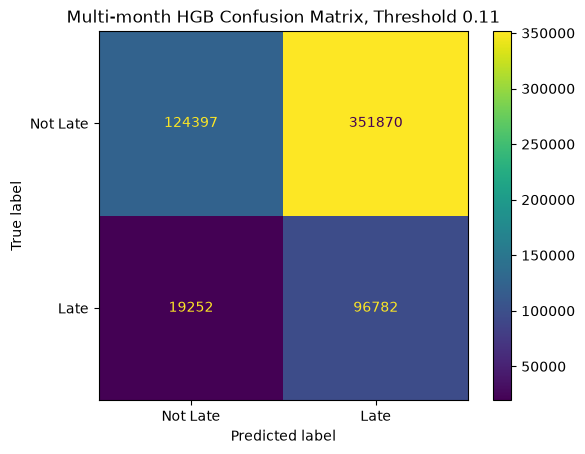

In [13]:
cm = confusion_matrix(y_test, best_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Late", "Late"]
)

disp.plot()
plt.title(f"Multi-month HGB Confusion Matrix, Threshold {best_threshold}")
plt.show()

In [14]:
Path("../visuals").mkdir(exist_ok=True)

multi_month_results_df.to_csv(
    "../visuals/multi_month_threshold_results.csv",
    index=False
)

comparison.to_csv(
    "../visuals/multi_month_comparison.csv",
    index=False
)

comparison

,model,train_months,test_month,threshold,accuracy,precision,recall,f1
0,January-only HGB,January random split,January random split,0.23,0.754696,0.391942,0.554163,0.459145
1,Multi-month HGB,January + February,March,0.11,0.373423,0.215717,0.834083,0.342782
